In [2]:
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv.zip.csv")

In [4]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
df.shape

(9994, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [18]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [12]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [13]:
df.sample(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
7496,Standard Class,Consumer,United States,Westminster,California,92683,West,Furniture,Furnishings,276.69,3,0.0,49.8042
1929,Second Class,Home Office,United States,Seattle,Washington,98105,West,Office Supplies,Storage,46.51,1,0.0,1.8604
1732,Standard Class,Consumer,United States,Dallas,Texas,75081,Central,Office Supplies,Storage,338.04,3,0.2,-33.8040
463,Standard Class,Home Office,United States,Phoenix,Arizona,85023,West,Furniture,Tables,1272.63,6,0.5,-814.4832
5949,Same Day,Corporate,United States,Southaven,Mississippi,38671,South,Technology,Accessories,299.97,3,0.0,125.9874


In [15]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [17]:
df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [20]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [22]:
df["Category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [24]:
df.nunique()

,0
Ship Mode,4
Segment,3
Country,1
City,531
State,49
Postal Code,631
Region,4
Category,3
Sub-Category,17
Sales,5825


In [28]:
df.duplicated().sum()

np.int64(17)

In [30]:
df = df.dropna()

In [35]:
df.columns = df.columns.str.strip()

In [37]:
# SQL
!pip install pandasql

In [39]:
from pandasql import sqldf

In [41]:
pysqldf = lambda q: sqldf(q, globals())

In [53]:
 #SQL QUERIES
 # TOTAL SALES

 pysqldf("SELECT SUM(Sales) AS Total_Sales FROM df")

,Total_Sales
0,2.297201e+06


In [55]:
#TOP 5 PRODUCTS
pysqldf("""
SELECT [Sub-Category], SUM(Sales) AS Total
FROM df
GROUP BY [Sub-Category]
ORDER BY Total DESC
LIMIT 5
""")

,Sub-Category,Total
0,Phones,330007.054
1,Chairs,328449.103
2,Storage,223843.608
3,Tables,206965.532
4,Binders,203412.733


In [57]:
#Sales by Category
pysqldf("""
SELECT Category, SUM(Sales) AS Total
FROM df
GROUP BY Category
""")

,Category,Total
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


In [63]:
#Monthly Sales Trend
pysqldf("""
SELECT strftime('%Y-%m', [Discount]) AS Month,
SUM(Sales) AS Total
FROM df
GROUP BY Month
ORDER BY Month
""")

,Month,Total
0,-4713-11,2.297201e+06


In [65]:
#BUSINESS ANALYSIS
#Sales by Region
pysqldf("""
SELECT Region, SUM(Sales) AS Total_Sales
FROM df
GROUP BY Region
ORDER BY Total_Sales DESC
""")

,Region,Total_Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


In [67]:
#Profit by Category
pysqldf("""
SELECT Category, SUM(Profit) AS Total_Profit
FROM df
GROUP BY Category
ORDER BY Total_Profit DESC
""")

,Category,Total_Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


In [70]:
#Loss-making categories
pysqldf("""
SELECT [Sub-Category], SUM(Profit) AS Total_Profit
FROM df
GROUP BY [Sub-Category]
HAVING Total_Profit < 0
""")

,Sub-Category,Total_Profit
0,Bookcases,-3472.5560
1,Supplies,-1189.0995
2,Tables,-17725.4811


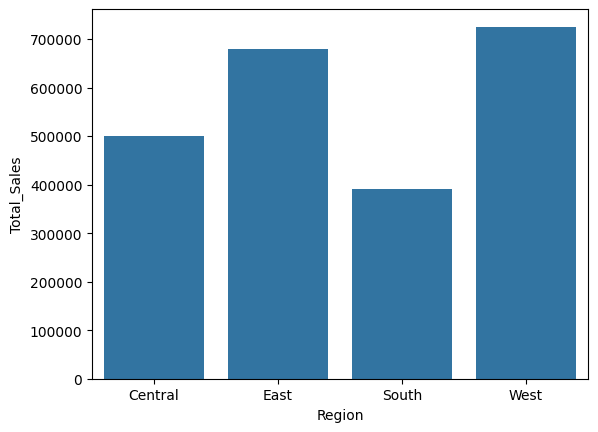

In [72]:
#VISUALIZATION
#Sales by Region
import seaborn as sns
import matplotlib.pyplot as plt

region_sales = pysqldf("""
SELECT Region, SUM(Sales) AS Total_Sales
FROM df
GROUP BY Region
""")

sns.barplot(x="Region", y="Total_Sales", data=region_sales)
plt.show()

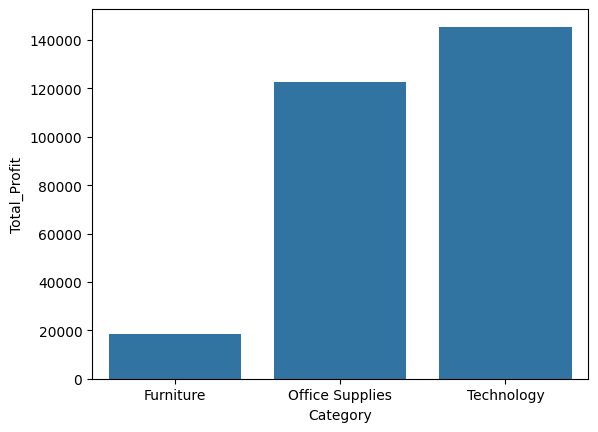

In [74]:
#Profit by Category
category_profit = pysqldf("""
SELECT Category, SUM(Profit) AS Total_Profit
FROM df
GROUP BY Category
""")

sns.barplot(x="Category", y="Total_Profit", data=category_profit)
plt.show()

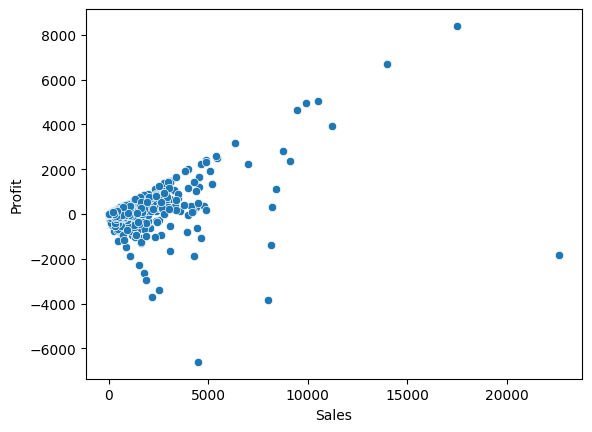

In [76]:
#Sales vs Profit
sns.scatterplot(x="Sales", y="Profit", data=df)
plt.show()